# 00 — JupyterLab 4.x Extensions

Recommended JupyterLab 4.x tools for Spark notebooks, benchmarking, visualization, SQL work, Git hygiene, and code quality.

## 00 — Environment check


In [1]:
import sys
import subprocess
from importlib.util import find_spec

def command_output(command):
    result = subprocess.run(command, shell=True, text=True, capture_output=True)
    return result.stdout.strip() or result.stderr.strip()

print(sys.version)
print(command_output("jupyter --version"))

3.10.12 (main, Mar  3 2026, 11:56:32) [GCC 11.4.0]
Selected Jupyter core packages...
IPython          : 8.39.0
ipykernel        : 7.2.0
ipywidgets       : 8.1.8
jupyter_client   : 8.8.0
jupyter_core     : 5.9.1
jupyter_server   : 2.17.0
jupyterlab       : 4.5.7
nbclient         : 0.10.4
nbconvert        : 7.17.1
nbformat         : 5.10.4
notebook         : not installed
qtconsole        : not installed
traitlets        : 5.14.3


## 01 — Recommended structure


In [2]:
import pandas as pd

recommended_packages = [
    ("ipywidgets", "Interactive controls", "Tune parameters, filters, benchmark settings, and demo inputs without editing code"),
    ("tqdm", "Progress bars", "Show progress for benchmark loops, repeated Spark actions, and batch validation"),
    ("plotly", "Interactive charts", "Visualize small aggregated benchmark or monitoring results with hover and zoom"),
    ("itables", "Interactive tables", "Inspect small Pandas results with search, sorting, paging, and horizontal scrolling"),
    ("jupysql", "SQL notebook cells", "Run SQL-style exploration against supported local engines directly from notebook cells"),
    ("duckdb", "Local analytical SQL", "Query Pandas, CSV, and Parquet locally before or after Spark processing"),
    ("nbdime", "Notebook diff and merge", "Review notebook changes in PRs using cell-aware diffs instead of raw JSON"),
    ("nbstripout", "Clean notebook commits", "Strip outputs and execution counts before committing notebooks"),
    ("black", "Python formatter", "Keep notebook and script code style consistent"),
    ("ruff", "Python linter", "Catch unused imports, simple mistakes, and bad patterns quickly"),
]

pd.DataFrame(recommended_packages, columns=["package", "what_it_does", "when_to_use"])


,package,what_it_does,when_to_use
0,ipywidgets,Interactive controls,"Tune parameters, filters, benchmark settings, ..."
1,tqdm,Progress bars,"Show progress for benchmark loops, repeated Sp..."
2,plotly,Interactive charts,Visualize small aggregated benchmark or monito...
3,itables,Interactive tables,"Inspect small Pandas results with search, sort..."
4,jupysql,SQL notebook cells,Run SQL-style exploration against supported lo...
5,duckdb,Local analytical SQL,"Query Pandas, CSV, and Parquet locally before ..."
6,nbdime,Notebook diff and merge,Review notebook changes in PRs using cell-awar...
7,nbstripout,Clean notebook commits,Strip outputs and execution counts before comm...
8,black,Python formatter,Keep notebook and script code style consistent
9,ruff,Python linter,"Catch unused imports, simple mistakes, and bad..."


## 02 — Import validation
Validates the active notebook kernel. Use this after rebuilding the Docker image to confirm that the running container actually contains the expected packages.



In [3]:
checks = [
    ("ipywidgets", "ipywidgets"),
    ("tqdm", "tqdm"),
    ("plotly", "plotly"),
    ("itables", "itables"),
    ("jupysql", "sql"),
    ("duckdb", "duckdb"),
    ("nbdime", "nbdime"),
    ("nbstripout", "nbstripout"),
    ("black", "black"),
    ("ruff", "ruff"),
]

pd.DataFrame(
    [(tool, module, find_spec(module) is not None) for tool, module in checks],
    columns=["tool", "import_name", "available"]
)

,tool,import_name,available
0,ipywidgets,ipywidgets,True
1,tqdm,tqdm,True
2,plotly,plotly,True
3,itables,itables,True
4,jupysql,sql,True
5,duckdb,duckdb,True
6,nbdime,nbdime,True
7,nbstripout,nbstripout,True
8,black,black,True
9,ruff,ruff,True


## 03 — ipywidgets
Interactive controls for notebook parameters. Use this for sliders, dropdowns, checkboxes, or buttons that change filters, benchmark settings, sample sizes, or Spark query parameters without editing code.



In [4]:
try:
    import ipywidgets as widgets
    from IPython.display import display

    metrics = [
        {"strategy": "broadcast", "seconds": 1.2},
        {"strategy": "shuffle", "seconds": 4.8},
        {"strategy": "aqe", "seconds": 3.1},
        {"strategy": "salting", "seconds": 2.6},
    ]

    threshold = widgets.FloatSlider(value=3.0, min=0.0, max=6.0, step=0.1, description="Max sec")
    output = widgets.Output()

    def render(change=None):
        output.clear_output()
        with output:
            for row in metrics:
                if row["seconds"] <= threshold.value:
                    print(f"{row['strategy']:<10} {row['seconds']}s")

    threshold.observe(render, names="value")
    display(threshold, output)
    render()
except Exception as exc:
    print(type(exc).__name__, exc)

FloatSlider(value=3.0, description='Max sec', max=6.0)

Output()

## 04 — tqdm progress bars


In [5]:
try:
    from tqdm.notebook import tqdm
    import time

    cases = ["baseline", "broadcast", "aqe", "salting"]
    for case in tqdm(cases, desc="Benchmark cases"):
        time.sleep(0.2)
except Exception as exc:
    print(type(exc).__name__, exc)

Benchmark cases:   0%|          | 0/4 [00:00<?, ?it/s]

## 05 — itables
Interactive tables for small Pandas DataFrames. Use this after Spark aggregation when the result is small enough to collect and inspect with search, sorting, pagination, and horizontal scrolling.



In [6]:
metrics_df = pd.DataFrame(
    [
        ("baseline", 5_000_000, 4.8, "shuffle"),
        ("broadcast", 5_000_000, 1.2, "broadcast"),
        ("aqe", 5_000_000, 3.1, "adaptive"),
        ("salting", 5_000_000, 2.6, "skew"),
    ],
    columns=["case", "rows", "seconds", "category"]
)

try:
    from itables import show
    show(metrics_df, scrollX=True, pageLength=10)
except Exception:
    metrics_df

Loading ITables v2.7.3 from the internet... (need help?)


## 06 — Plotly
Interactive charts for small aggregated results. Use this for benchmark summaries, runtime comparisons, distribution charts, and exploratory visualizations where hover and zoom help.



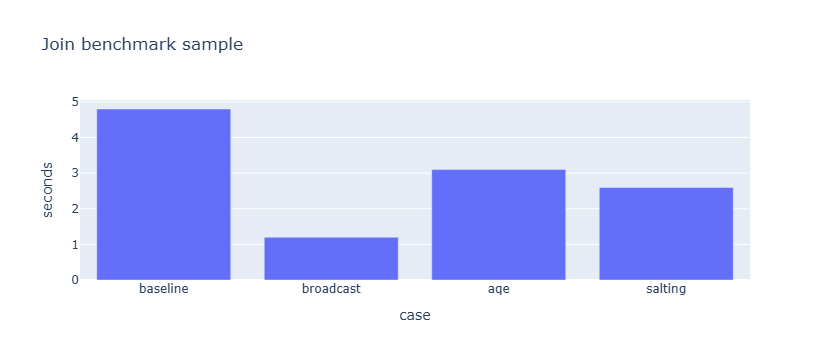

In [7]:
try:
    import plotly.express as px
    fig = px.bar(metrics_df, x="case", y="seconds", hover_data=["rows", "category"], title="Join benchmark sample")
    fig.show()
except Exception as exc:
    print(type(exc).__name__, exc)

## 07 — DuckDB
Fast local SQL engine for Pandas DataFrames and local CSV/Parquet files. Use this for quick local analysis, pre-checks, notebook metadata queries, and small or medium file inspection without launching a Spark job.



In [8]:
try:
    import duckdb
    duckdb.sql("""
        SELECT category,
               COUNT(*) AS cases,
               ROUND(AVG(seconds), 3) AS avg_seconds
        FROM metrics_df
        GROUP BY category
        ORDER BY avg_seconds
    """).show()
except Exception as exc:
    print(type(exc).__name__, exc)

┌───────────┬───────┬─────────────┐
│ category  │ cases │ avg_seconds │
│  varchar  │ int64 │   double    │
├───────────┼───────┼─────────────┤
│ broadcast │     1 │         1.2 │
│ skew      │     1 │         2.6 │
│ adaptive  │     1 │         3.1 │
│ shuffle   │     1 │         4.8 │
└───────────┴───────┴─────────────┘



## 08 — Optional Spark integration
Demonstrates how extension output can integrate with Spark when distributed SQL is needed. This keeps the notebook useful even when some sections are local-only, while still validating the Spark container workflow.



In [9]:
try:
    from pyspark.sql import SparkSession

    spark = (
        SparkSession.builder
        .appName("jupyterlab_4_extensions")
        .config("spark.sql.warehouse.dir", "/tmp/spark-warehouse")
        .getOrCreate()
    )

    spark_metrics = spark.createDataFrame(metrics_df)
    spark_metrics.createOrReplaceTempView("extension_metrics")

    spark.sql("""
    SELECT category,
           COUNT(*) AS cases,
           ROUND(AVG(seconds), 3) AS avg_seconds
    FROM extension_metrics
    GROUP BY category
    ORDER BY avg_seconds
    """).show(truncate=False)
except Exception as exc:
    print(type(exc).__name__, exc)

+---------+-----+-----------+
|category |cases|avg_seconds|
+---------+-----+-----------+
|broadcast|1    |1.2        |
|skew     |1    |2.6        |
|adaptive |1    |3.1        |
|shuffle  |1    |4.8        |
+---------+-----+-----------+



## 09 — nbdime
Notebook-aware diff and merge tool. Use this in pull requests because it compares notebook cells more clearly than raw JSON diffs.



In [10]:
nbdime_commands = """
nbdime config-git --enable
nbdiff old_notebook.ipynb new_notebook.ipynb
nbmerge base.ipynb local.ipynb remote.ipynb
""".strip()

print(nbdime_commands)

nbdime config-git --enable
nbdiff old_notebook.ipynb new_notebook.ipynb
nbmerge base.ipynb local.ipynb remote.ipynb


## 10 — nbstripout
Removes notebook outputs and execution counts before commit. Use this to keep Git history clean, reduce noisy diffs, and avoid committing large generated outputs.



In [11]:
nbstripout_commands = """
nbstripout --install
nbstripout notebooks/**/*.ipynb
git diff --stat
""".strip()

print(nbstripout_commands)

nbstripout --install
nbstripout notebooks/**/*.ipynb
git diff --stat


## 11 — black and ruff
Black formats Python code consistently; Ruff catches common Python issues quickly. Use these tools when notebooks are reviewed, exported to scripts, or maintained by multiple people.



In [12]:
quality_commands = """
black notebooks scripts
ruff check notebooks scripts
ruff check notebooks scripts --fix
""".strip()

print(quality_commands)

black notebooks scripts
ruff check notebooks scripts
ruff check notebooks scripts --fix
